In [1]:
import geopandas as gpd

geo = gpd.read_file('nga_admin1.geojson')
print(geo.columns)  # first, see what the state-name column is actually called

Index(['adm1_name', 'adm1_name1', 'adm1_name2', 'adm1_name3', 'adm1_pcode',
       'adm0_name', 'adm0_name1', 'adm0_name2', 'adm0_name3', 'adm0_pcode',
       'valid_on', 'valid_to', 'area_sqkm', 'version', 'lang', 'lang1',
       'lang2', 'lang3', 'adm1_ref_name', 'center_lat', 'center_lon',
       'geometry'],
      dtype='object')


In [2]:
import pandas as pd
df_immu = pd.read_csv('immunization_subnational_nga.csv')
df_qs = pd.read_csv('dhs-quickstats_subnational_nga.csv')
df_anth = pd.read_csv('anthropometry_subnational_nga.csv')

print(df_immu.columns)
print(df_qs.columns)
print(df_anth.columns)

Index(['ISO3', 'Location', 'DataId', 'Indicator', 'Value', 'Precision',
       'DHS_CountryCode', 'CountryName', 'SurveyYear', 'SurveyId',
       'IndicatorId', 'IndicatorOrder', 'IndicatorType', 'CharacteristicId',
       'CharacteristicOrder', 'CharacteristicCategory', 'CharacteristicLabel',
       'ByVariableId', 'ByVariableLabel', 'IsTotal', 'IsPreferred', 'SDRID',
       'RegionId', 'SurveyYearLabel', 'SurveyType', 'DenominatorWeighted',
       'DenominatorUnweighted', 'CILow', 'CIHigh', 'LevelRank'],
      dtype='object')
Index(['ISO3', 'Location', 'DataId', 'Indicator', 'Value', 'Precision',
       'DHS_CountryCode', 'CountryName', 'SurveyYear', 'SurveyId',
       'IndicatorId', 'IndicatorOrder', 'IndicatorType', 'CharacteristicId',
       'CharacteristicOrder', 'CharacteristicCategory', 'CharacteristicLabel',
       'ByVariableId', 'ByVariableLabel', 'IsTotal', 'IsPreferred', 'SDRID',
       'RegionId', 'SurveyYearLabel', 'SurveyType', 'DenominatorWeighted',
       'Denominator

In [3]:
combined = pd.concat([df_immu, df_anth, df_qs], ignore_index=True)

In [4]:
print(combined['Indicator'].unique())

['BCG vaccination received' 'DPT 1 vaccination received'
 'DPT 2 vaccination received' 'DPT 3 vaccination received'
 'Polio 1 vaccination received' 'Polio 2 vaccination received'
 'Polio 3 vaccination received' 'Measles vaccination received'
 'Fully vaccinated (8 basic antigens)' 'Received no vaccinations'
 'Number of children 12-23 months'
 'Number of children 12-23 months (unweighted)'
 'Polio 0 vaccination received' 'Hepatitis 0 vaccination received'
 'Hepatitis 1 vaccination received' 'Hepatitis 2 vaccination received'
 'Hepatitis 3 vaccination received'
 'Haemophilus influenza type b 1 vaccination received'
 'Haemophilus influenza type b 2 vaccination received'
 'Haemophilus influenza type b 3 vaccination received'
 'Children severely stunted' 'Children stunted'
 'Mean height for age of children' 'Children severely wasted'
 'Children wasted' 'Children overweight'
 'Mean weight for height of children' 'Children severely underweight'
 'Children underweight' 'Children overweight for 

In [5]:
# List of the 36 states + FCT (Federal Capital Territory)
valid_states = [
    'Abia', 'Adamawa', 'Akwa Ibom', 'Anambra', 'Bauchi', 'Bayelsa', 'Benue',
    'Borno', 'Cross River', 'Delta', 'Ebonyi', 'Edo', 'Ekiti', 'Enugu',
    'Gombe', 'Imo', 'Jigawa', 'Kaduna', 'Kano', 'Katsina', 'Kebbi', 'Kogi',
    'Kwara', 'Lagos', 'Nasarawa', 'Niger', 'Ogun', 'Ondo', 'Osun', 'Oyo',
    'Plateau', 'Rivers', 'Sokoto', 'Taraba', 'Yobe', 'Zamfara',
    'FCT Abuja'  # check exact spelling used in your file
]

key_indicators = [
    'Fully vaccinated (8 basic antigens)',
    'Children stunted',
    'Place of delivery: Health facility',
    'Women with secondary or higher education'
]

dashboard_data = combined[combined['Indicator'].isin(key_indicators)]
dashboard_data = dashboard_data[dashboard_data['Location'].isin(valid_states)]

pivoted = dashboard_data.pivot_table(
    index='Location',
    columns='Indicator',
    values='Value'
).reset_index()

# Check the real alphabetical order BEFORE renaming — don't skip this step
print(pivoted.columns)

Index(['Location', 'Children stunted', 'Fully vaccinated (8 basic antigens)',
       'Place of delivery: Health facility',
       'Women with secondary or higher education'],
      dtype='object', name='Indicator')


In [6]:
print(dashboard_data.groupby('Indicator')['Location'].nunique())

Indicator
Children stunted                            37
Fully vaccinated (8 basic antigens)         37
Place of delivery: Health facility          37
Women with secondary or higher education    37
Name: Location, dtype: int64


In [ ]:
pivoted.columns = ['Location', 'stunting_rate', 'immunization_rate', 'birth_facility_rate', 'education_rate']

# Sanity check against a state you already trust
print(pivoted[pivoted['Location'] == 'Sokoto'])

   Location  stunting_rate  immunization_rate  birth_facility_rate  \
33   Sokoto      49.733333                4.8               8.3875   

    education_rate  
33           10.08  


In [8]:
geo_states = sorted(geo['adm1_name'].unique())
health_states = sorted(pivoted['Location'].unique())

print("In geojson but not in health data:", set(geo_states) - set(health_states))
print("In health data but not in geojson:", set(health_states) - set(geo_states))

In geojson but not in health data: set()
In health data but not in geojson: set()


In [9]:
pivoted['Location'] = pivoted['Location'].replace('FCT Abuja', 'Federal Capital Territory')

# Re-verify
health_states = sorted(pivoted['Location'].unique())
print("Still mismatched:", set(geo_states) - set(health_states))

Still mismatched: set()


In [10]:
pivoted.to_csv('dashboard_final_data.csv', index=False)

## EXPLORATORY DATA ANALYSIS

In [26]:
print(pivoted[['immunization_rate', 'birth_facility_rate', 'stunting_rate', 'education_rate']].corr())

                     immunization_rate  birth_facility_rate  stunting_rate  \
immunization_rate             1.000000             0.746061      -0.800964   
birth_facility_rate           0.746061             1.000000      -0.870768   
stunting_rate                -0.800964            -0.870768       1.000000   
education_rate                0.879666             0.879397      -0.931157   

                     education_rate  
immunization_rate          0.879666  
birth_facility_rate        0.879397  
stunting_rate             -0.931157  
education_rate             1.000000  


In [28]:
print("=== Top 5 & Bottom 5: Immunization ===")
print(pivoted.sort_values('immunization_rate', ascending=False)[['Location','immunization_rate']].head(5))
print(pivoted.sort_values('immunization_rate')[['Location','immunization_rate']].head(5))

print("\n=== Top 5 & Bottom 5: Stunting (lower = better here) ===")
print(pivoted.sort_values('stunting_rate')[['Location','stunting_rate']].head(5))
print(pivoted.sort_values('stunting_rate', ascending=False)[['Location','stunting_rate']].head(5))

print("\n=== Top 5 & Bottom 5: Birth facility delivery ===")
print(pivoted.sort_values('birth_facility_rate', ascending=False)[['Location','birth_facility_rate']].head(5))
print(pivoted.sort_values('birth_facility_rate')[['Location','birth_facility_rate']].head(5))

print("\n=== Top 5 & Bottom 5: Education (secondary or higher) ===")
print(pivoted.sort_values('education_rate', ascending=False)[['Location','education_rate']].head(5))
print(pivoted.sort_values('education_rate')[['Location','education_rate']].head(5))

=== Top 5 & Bottom 5: Immunization ===
       Location  immunization_rate
16          Imo          61.366667
24        Lagos          60.800000
3       Anambra          58.700000
8   Cross River          55.700000
11          Edo          55.633333
   Location  immunization_rate
33   Sokoto           4.800000
21    Kebbi           6.266667
36  Zamfara           6.366667
7     Borno          20.033333
34   Taraba          21.500000

=== Top 5 & Bottom 5: Stunting (lower = better here) ===
   Location  stunting_rate
13    Enugu      13.900000
32   Rivers      15.066667
3   Anambra      15.100000
11      Edo      15.133333
24    Lagos      17.166667
   Location  stunting_rate
21    Kebbi      62.233333
20  Katsina      61.200000
17   Jigawa      59.566667
36  Zamfara      56.966667
4    Bauchi      55.733333

=== Top 5 & Bottom 5: Birth facility delivery ===
   Location  birth_facility_rate
16      Imo              93.1000
29     Osun              88.9500
3   Anambra              87.4000


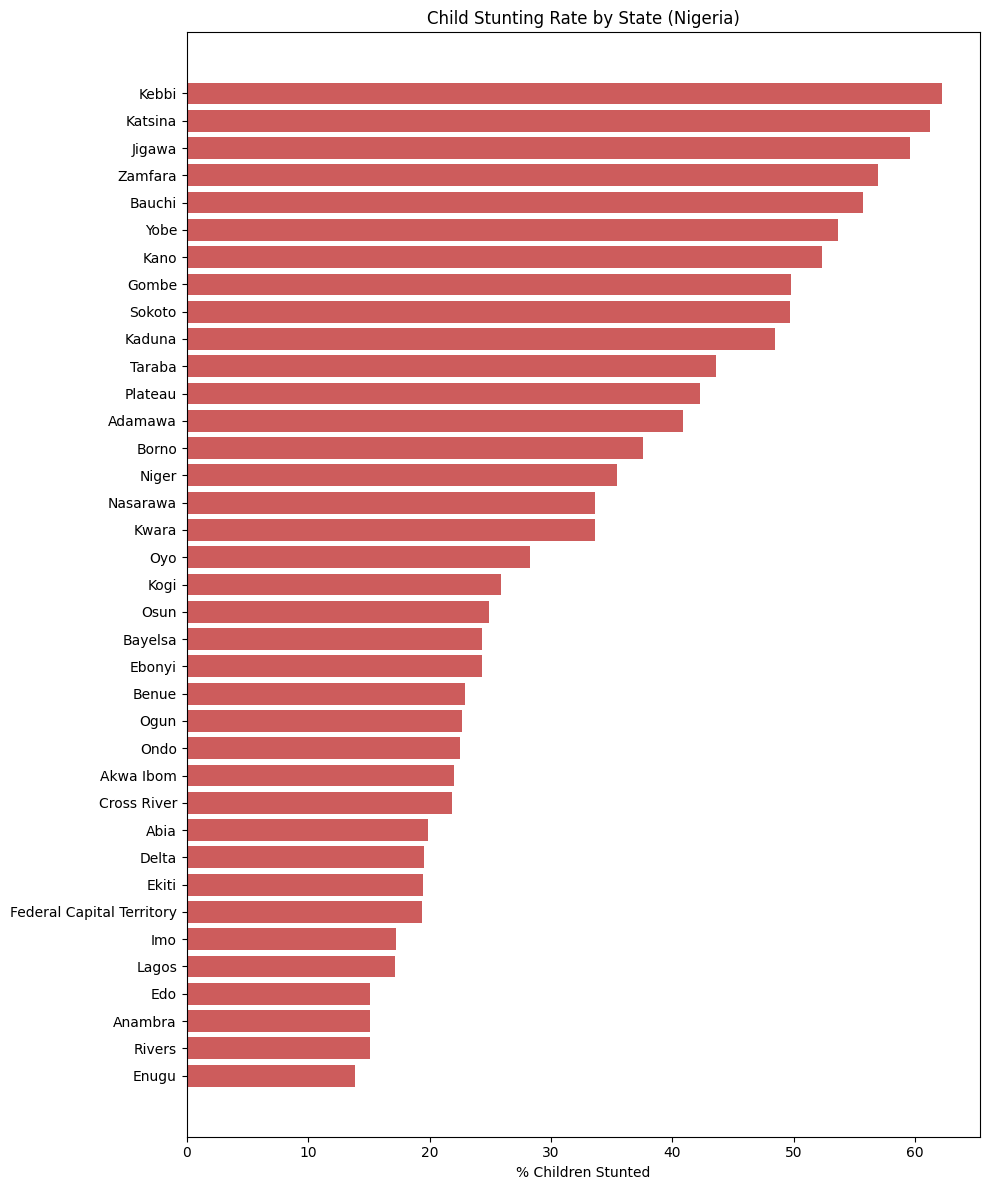

In [29]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(10,12))
sorted_data = pivoted.sort_values('stunting_rate', ascending=True)
ax.barh(sorted_data['Location'], sorted_data['stunting_rate'], color='indianred')
ax.set_xlabel('% Children Stunted')
ax.set_title('Child Stunting Rate by State (Nigeria)')
plt.tight_layout()
plt.savefig('stunting_by_state.png', dpi=150)
plt.show()

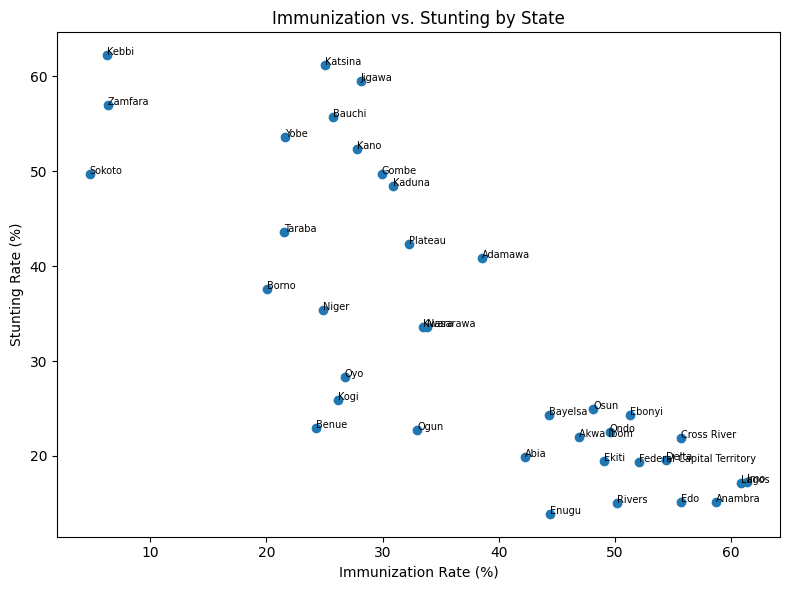

In [30]:
fig, ax = plt.subplots(figsize=(8,6))
ax.scatter(pivoted['immunization_rate'], pivoted['stunting_rate'])
for i, row in pivoted.iterrows():
    ax.annotate(row['Location'], (row['immunization_rate'], row['stunting_rate']), fontsize=7)
ax.set_xlabel('Immunization Rate (%)')
ax.set_ylabel('Stunting Rate (%)')
ax.set_title('Immunization vs. Stunting by State')
plt.tight_layout()
plt.savefig('immunization_vs_stunting.png', dpi=150)
plt.show()